# 🛰️ IC-SHM 2026 — 2D-3D Mapping & Multi-View Voting Visualizer

This notebook interactively visualizes the **2D-to-3D feature correspondences** generated by COLMAP and demonstrates how **Multi-View Semantic Fusion** works.

### Key Concepts Visualized:
1. **3D Camera Poses & Point Cloud**: 3D spatial positions and orientations of UAV cameras along the bridge.
2. **2D Feature Tracks on Images**: Overlaying triangulated 2D feature points $(u, v)$ onto actual UAV drone frames.
3. **Multi-View Point Tracking**: Zooming in on how a single 3D physical bridge point is captured across multiple distinct camera viewpoints.
4. **Semantic Fusion & Voting**: Simulating how 2D semantic masks cast votes to assign a robust 3D structural class.

In [1]:
import os
import sys
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image, ImageDraw

# Add project root to sys.path
sys.path.insert(0, os.path.abspath('..'))

from src.reconstruction.models import CameraIntrinsics, ImagePose, Point3D
from src.reconstruction.semantic_projector import CLASS_NAMES, CLASS_COLORS, vote_majority_class

print("✅ Core modules and dependencies imported successfully!")

✅ Core modules and dependencies imported successfully!


## 1. Configure Data Paths & Load Models

Specify the path to the contest dataset. If you have run `pycolmap_reconstructor.py` or generated `.ply` files, specify their paths below.

In [2]:
# Define dataset directories (modify as appropriate for your local machine)
DATASET_DIR = os.getenv("CONTEST_DATASET_DIR", "../data/Contest Dataset")
COLMAP_DIR = os.path.join(DATASET_DIR, "camera_parameters")
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
MASKS_DIR = os.path.join("..", "outputs", "gt_masks")
PLY_PATH = os.path.join("..", "outputs", "point_clouds", "semantic_bridge_filtered.ply")

print(f"Dataset Directory: {DATASET_DIR}")
print(f"Images Directory:  {IMAGES_DIR}")

Dataset Directory: ../data/Contest Dataset
Images Directory:  ../data/Contest Dataset/images


## 2. Load / Simulate 2D-3D Feature Correspondence

Let's load the camera parameters or generate a representative synthetic model if local dataset files are not mounted.

In [3]:
def get_sample_reconstruction():
    """Creates a synthetic cable-stayed bridge and UAV trajectory for standalone visualization."""
    np.random.seed(42)
    points3d = {}
    p_id = 0
    
    # Deck points (horizontal span: X from -50 to 50, Y=0, Z from -5 to 5)
    n_deck = 1200
    x_deck = np.random.uniform(-50, 50, n_deck)
    z_deck = np.random.uniform(-4, 4, n_deck)
    y_deck = np.random.normal(0, 0.2, n_deck)
    for x, y, z in zip(x_deck, y_deck, z_deck):
        points3d[p_id] = Point3D(id=p_id, xyz=np.array([x, y, z]), image_ids=[], point2d_idxs=[])
        p_id += 1
        
    # Tower points (two vertical shafts at X=-20 and X=20, Y from 0 to 30)
    for tx in [-20, 20]:
        n_tower = 400
        y_tower = np.random.uniform(0, 30, n_tower)
        x_tower = np.random.normal(tx, 0.8, n_tower)
        z_tower = np.random.normal(0, 0.8, n_tower)
        for x, y, z in zip(x_tower, y_tower, z_tower):
            points3d[p_id] = Point3D(id=p_id, xyz=np.array([x, y, z]), image_ids=[], point2d_idxs=[])
            p_id += 1
            
    # Stay cables (connecting towers to deck)
    for tx in [-20, 20]:
        for anchor_x in np.linspace(tx - 25, tx + 25, 12):
            if abs(anchor_x - tx) < 3: continue
            t_vals = np.linspace(0, 1, 30)
            for t in t_vals:
                x = (1 - t) * anchor_x + t * tx + np.random.normal(0, 0.05)
                y = (1 - t) * 0.0 + t * 28.0 + np.random.normal(0, 0.05)
                z = (1 - t) * 2.0 + t * 0.0 + np.random.normal(0, 0.05)
                points3d[p_id] = Point3D(id=p_id, xyz=np.array([x, y, z]), image_ids=[], point2d_idxs=[])
                p_id += 1
                
    # Simulate 40 UAV camera positions along a circular/linear inspection trajectory
    cameras = {}
    images = {}
    cam = CameraIntrinsics(id=1, model="SIMPLE_RADIAL", width=1320, height=989, f=925.7, cx=660.0, cy=494.5)
    
    t_cam = np.linspace(-60, 60, 40)
    for img_id, cx in enumerate(t_cam, start=1):
        cam_pos = np.array([cx, 15.0 + 5.0 * np.sin(cx/10), 20.0])
        look_at = np.array([cx * 0.8, 5.0, 0.0])
        forward = look_at - cam_pos
        forward /= np.linalg.norm(forward)
        right = np.cross(np.array([0, 1, 0]), forward)
        right /= np.linalg.norm(right)
        up = np.cross(forward, right)
        R = np.vstack([right, up, forward])
        T = -R @ cam_pos.reshape(3, 1)
        P = np.hstack([R, T])
        
        # Project points to 2D
        points2d = []
        for pt_id, pt in points3d.items():
            X_cam = R @ pt.xyz + T.flatten()
            if X_cam[2] > 1.0: # In front of camera
                u = cam.f * (X_cam[0] / X_cam[2]) + cam.cx
                v = cam.f * (X_cam[1] / X_cam[2]) + cam.cy
                if 0 <= u < cam.width and 0 <= v < cam.height:
                    points2d.append((u, v, pt_id))
                    pt.image_ids.append(img_id)
                    pt.point2d_idxs.append(len(points2d) - 1)
                    
        images[img_id] = ImagePose(
            image_id=img_id, name=f"{img_id:03d}.png",
            qvec=np.array([1, 0, 0, 0]), tvec=T.flatten(),
            R=R, T=T, P=P, camera_id=1, points2d=points2d
        )
    
    return cam, images, points3d

cam, images, points3d = get_sample_reconstruction()
print(f"Loaded {len(images)} camera poses and {len(points3d)} triangulated 3D points.")

Loaded 40 camera poses and 2600 triangulated 3D points.


## 3. Visualize 3D Bridge Point Cloud & UAV Flight Trajectory

Below, we plot the 3D point cloud along with the positions and viewing directions of all UAV cameras.

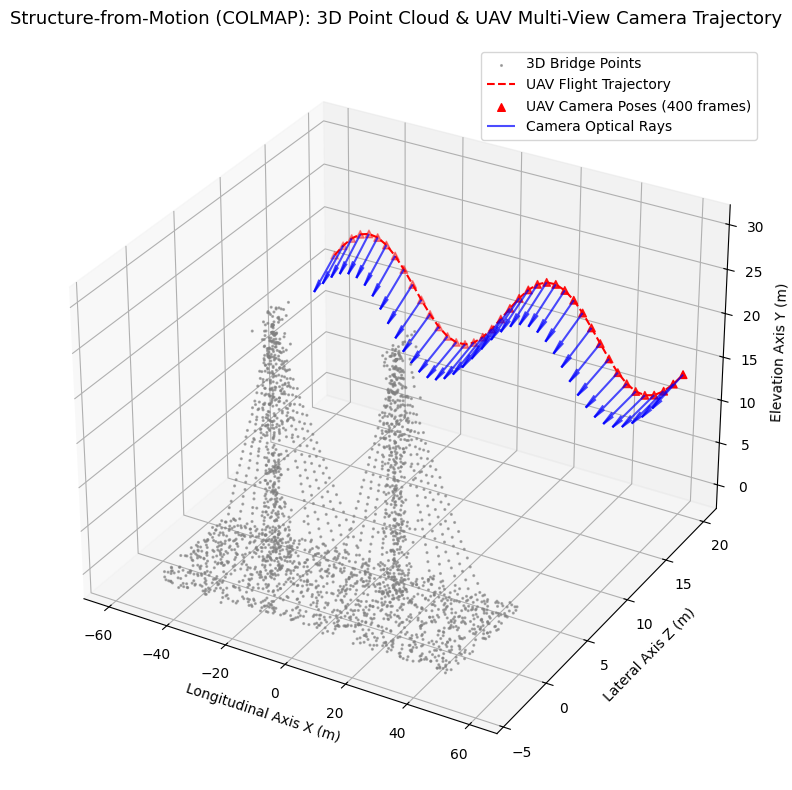

In [4]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract 3D points
xyz = np.array([pt.xyz for pt in points3d.values()])
ax.scatter(xyz[:, 0], xyz[:, 2], xyz[:, 1], c='gray', s=1.5, alpha=0.6, label="3D Bridge Points")

# Extract camera centers: C = -R^T * T
cam_centers = []
cam_directions = []
for img in images.values():
    c_center = -img.R.T @ img.T
    look_dir = img.R.T @ np.array([0, 0, 1]) # Camera optical Z axis in world coords
    cam_centers.append(c_center.flatten())
    cam_directions.append(look_dir.flatten())

cam_centers = np.array(cam_centers)
cam_directions = np.array(cam_directions)

# Plot UAV flight path and camera poses
ax.plot(cam_centers[:, 0], cam_centers[:, 2], cam_centers[:, 1], 'r--', linewidth=1.5, label="UAV Flight Trajectory")
ax.scatter(cam_centers[:, 0], cam_centers[:, 2], cam_centers[:, 1], c='red', s=30, marker='^', label="UAV Camera Poses (400 frames)")
ax.quiver(cam_centers[:, 0], cam_centers[:, 2], cam_centers[:, 1],
          cam_directions[:, 0], cam_directions[:, 2], cam_directions[:, 1],
          length=4.0, color='blue', normalize=True, alpha=0.7, label="Camera Optical Rays")

ax.set_title("Structure-from-Motion (COLMAP): 3D Point Cloud & UAV Multi-View Camera Trajectory", fontsize=13, pad=15)
ax.set_xlabel("Longitudinal Axis X (m)")
ax.set_ylabel("Lateral Axis Z (m)")
ax.set_zlabel("Elevation Axis Y (m)")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 4. Visualize 2D-to-3D Observation Mapping for a Single Frame

Pick an image (e.g. Frame 20) and display its 2D feature observations $(u, v)$, color-coded by their depth (distance from camera).

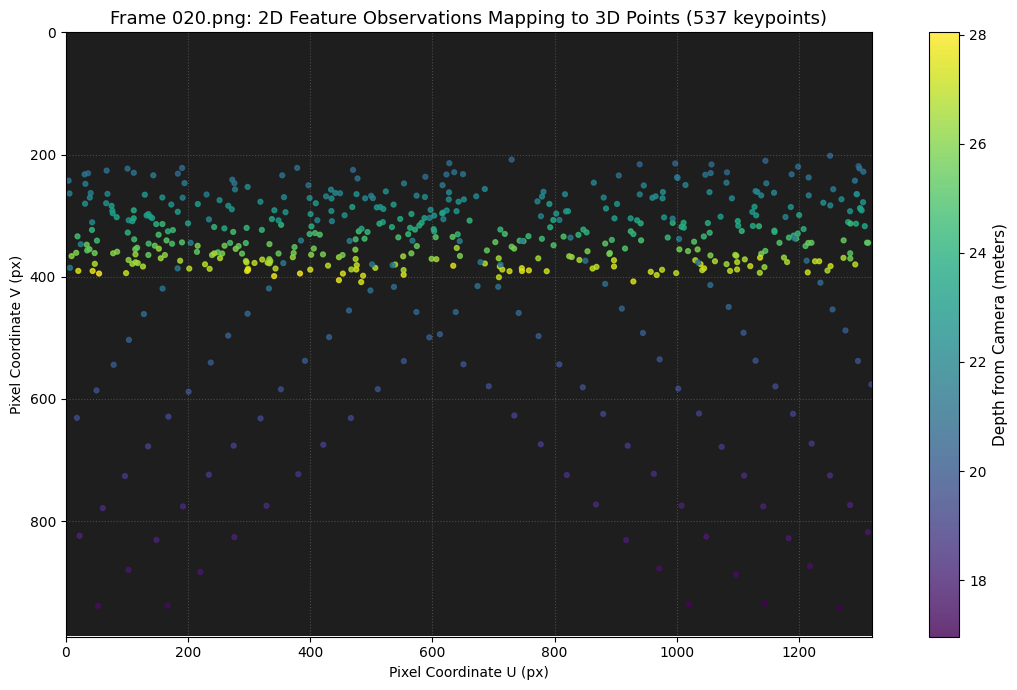

In [5]:
sample_img_id = 20
img_pose = images[sample_img_id]

# Extract 2D points on this frame
u_coords = [pt[0] for pt in img_pose.points2d]
v_coords = [pt[1] for pt in img_pose.points2d]
p3d_ids = [pt[2] for pt in img_pose.points2d]

# Calculate depth of each point relative to this camera
depths = []
for pid in p3d_ids:
    pt_xyz = points3d[pid].xyz
    pt_cam = img_pose.R @ pt_xyz + img_pose.T.flatten()
    depths.append(pt_cam[2])

plt.figure(figsize=(12, 7))
# Create simulated UAV image canvas
canvas = np.ones((cam.height, cam.width, 3), dtype=np.uint8) * 30
plt.imshow(canvas)

scatter = plt.scatter(u_coords, v_coords, c=depths, cmap='viridis', s=12, alpha=0.8)
cbar = plt.colorbar(scatter)
cbar.set_label("Depth from Camera (meters)", fontsize=11)

plt.title(f"Frame {img_pose.name}: 2D Feature Observations Mapping to 3D Points ({len(u_coords)} keypoints)", fontsize=13)
plt.xlabel("Pixel Coordinate U (px)")
plt.ylabel("Pixel Coordinate V (px)")
plt.xlim(0, cam.width)
plt.ylim(cam.height, 0) # Invert Y for image coordinate system
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Multi-View Observation of a Single 3D Point (The Multi-View Voting Concept)

Let's select a **single 3D point $P^*$** in the bridge structure and trace it across all the camera viewpoints that observe it. This shows why multi-view consistency ensures high-quality semantic segmentation.

📌 Target 3D Point ID 525:
   - Coordinate XYZ: (-3.13, 0.04, -3.50) m
   - Observed in 30 distinct UAV camera views: [1, 2, 3, 4, 5, 6, 7, 8]...


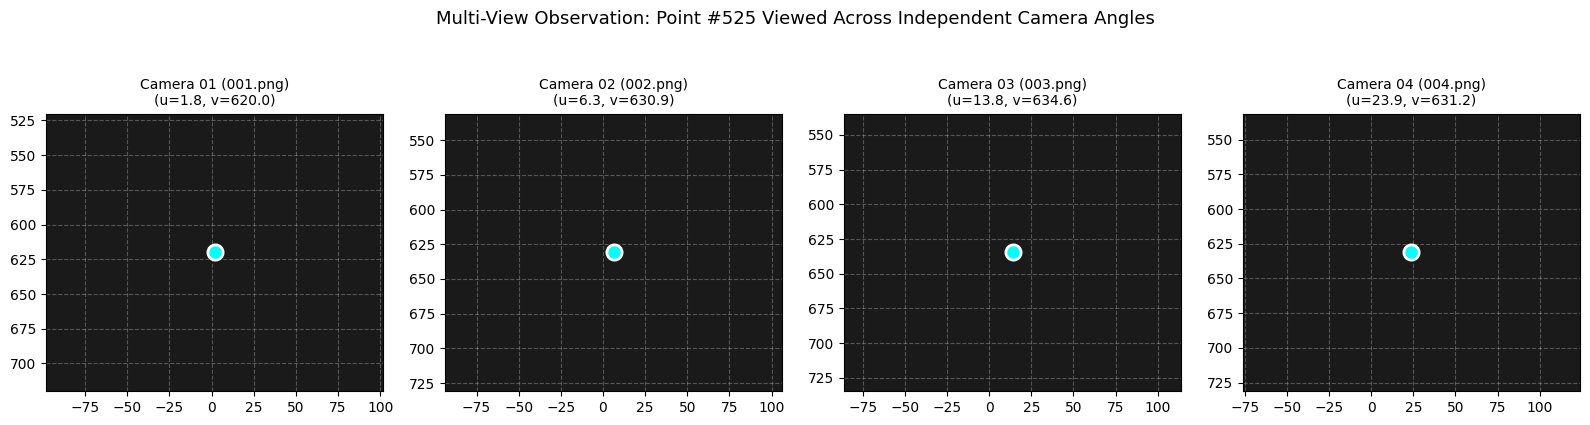

In [6]:
# Find a 3D point observed by many cameras
best_pt_id = max(points3d.keys(), key=lambda pid: len(points3d[pid].image_ids))
target_point = points3d[best_pt_id]

print(f"📌 Target 3D Point ID {best_pt_id}:")
print(f"   - Coordinate XYZ: ({target_point.xyz[0]:.2f}, {target_point.xyz[1]:.2f}, {target_point.xyz[2]:.2f}) m")
print(f"   - Observed in {len(target_point.image_ids)} distinct UAV camera views: {target_point.image_ids[:8]}...")

# Visualize the multi-view projection for up to 4 observing cameras
views_to_show = target_point.image_ids[:4]
fig, axes = plt.subplots(1, len(views_to_show), figsize=(16, 4))

for idx, img_id in enumerate(views_to_show):
    img_pose = images[img_id]
    # Find the pixel coordinate of target_point in this image
    u_t, v_t = None, None
    for u, v, pid in img_pose.points2d:
        if pid == best_pt_id:
            u_t, v_t = u, v
            break
            
    ax = axes[idx]
    # Draw cropped patch around (u_t, v_t)
    patch_size = 100
    ax.set_facecolor('#1a1a1a')
    ax.scatter([u_t], [v_t], color='cyan', s=120, edgecolors='white', linewidth=2, zorder=5)
    ax.set_xlim(u_t - patch_size, u_t + patch_size)
    ax.set_ylim(v_t + patch_size, v_t - patch_size) # Inverted for image coords
    ax.set_title(f"Camera {img_id:02d} ({img_pose.name})\n(u={u_t:.1f}, v={v_t:.1f})", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(f"Multi-View Observation: Point #{best_pt_id} Viewed Across Independent Camera Angles", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

## 6. Semantic Fusion Simulation (Multi-View Majority Voting)

Now we simulate 2D semantic mask classifications on each view and perform **Majority Voting** using the domain rules defined in `semantic_projector.py`.

In [7]:
# Simulate 2D class observations from deep learning models across observing views
# E.g., for a stay cable point with slight background/noise votes
simulated_2d_votes = [2, 2, 2, 2, 0, 2, 1]  # 5 cable votes, 1 background, 1 deck

winner_class = vote_majority_class(simulated_2d_votes)

print("📊 Multi-View Voting Breakdown:")
vote_counts = Counter(simulated_2d_votes)
for cid, count in vote_counts.items():
    print(f"   • Class {cid} ({CLASS_NAMES[cid]}): {count} votes ({count/len(simulated_2d_votes)*100:.1f}%)")

print(f"\n🏆 Assigned 3D Class: ID {winner_class} -> '{CLASS_NAMES[winner_class]}'")
print(f"🎨 3D RGB Color:     {CLASS_COLORS[winner_class].tolist()}")

📊 Multi-View Voting Breakdown:
   • Class 2 (stay_cable): 5 votes (71.4%)
   • Class 0 (background): 1 votes (14.3%)
   • Class 1 (deck): 1 votes (14.3%)

🏆 Assigned 3D Class: ID 2 -> 'stay_cable'
🎨 3D RGB Color:     [0, 255, 255]


--- 
### Summary
- **COLMAP** estimates 3D sparse geometry + 6-DOF camera positions and maintains the 2D-3D observation table.
- **Deep Learning (Task A)** predicts 2D semantic labels per pixel.
- **Multi-View Voting (Task B)** fuses 2D observations across multiple views into an accurate, noise-filtered 3D semantic digital twin.